In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from datetime import datetime
import time
import re

In [2]:
def get_rmb_mid_rate_raw(start, end):
    url='https://www.safe.gov.cn/AppStructured/hlw/RMBQuery.do'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/111.0.0.0 Safari/537.36'}
    data={'startDate': start, 
            'endDate': end,
            'queryYN': 'true'}
    r=requests.post(url, headers=headers, data=data)
    df=pd.read_html(r.content)[4]
    return df

In [3]:
def get_mid_rate(start_date, end_date):
    today=datetime.today()
    date_range=[i for i in range(pd.to_datetime(start_date).year,
                                pd.to_datetime(end_date).year+1)]
    dfs=[]
    for year in date_range:
        if year==today.year:
            start=datetime(year, 1, 1)
            end=today
        else:
            start=datetime(year, 1, 1)
            end=datetime(year, 12, 31)
        dfs.append(get_rmb_mid_rate_raw(start.strftime('%Y-%m-%d'), 
                                        end.strftime('%Y-%m-%d')))
    df=pd.concat(dfs)
    df['date']=pd.to_datetime(df['日期'])
    df=df.set_index('date')
    df=df.sort_index()
    return df

In [4]:
start_date='2023-01-01'
end_date='2025-08-25'
df=get_mid_rate(start_date, end_date)

<Axes: xlabel='date'>

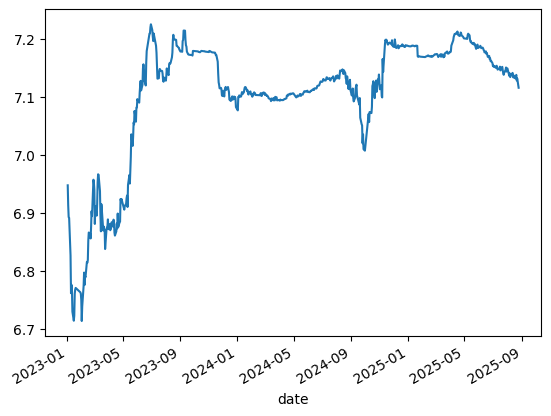

In [5]:
(df['美元']/100).plot()